# Predicting Trametinib Sensitivity in Cancer Cell Lines

## Introduction

This project investigates whether cancer driver mutation profiles can be used to predict the sensitivity of cancer cell lines to **Trametinib**, a small-molecule inhibitor of the MAPK signalling pathway.

Drug-response data from the Genomics of Drug Sensitivity in Cancer (GDSC) are integrated with driver mutation data from Cell Model Passports using Sanger Model IDs.

The primary objective is to explore relationships between genomic alterations and experimentally measured Trametinib response (LN_IC50) and, subsequently, to develop machine learning models that predict drug sensitivity from genomic features.

### Research Question

**Can cancer driver mutation profiles predict cancer cell line sensitivity to Trametinib?**

### Initial Objectives

1. Explore and validate the GDSC drug-response data.
2. Explore the cancer driver mutation data.
3. Identify cancer cell lines with both Trametinib response and mutation data.
4. Investigate the prevalence of mutations in MAPK pathway and related cancer genes.
5. Construct a machine-learning-ready dataset linking genomic features to Trametinib response.

## Notebook Contents

This notebook focuses on the initial exploration and preparation of the project data alongside exploratory data analysis.

The analysis includes:

1. Loading the GDSC drug-response dataset.
2. Inspecting dataset dimensions, variables, and missing values.
3. Exploring the distribution of drug-response measurements.
4. Identifying Trametinib-treated cancer cell lines.
5. Loading and exploring the Cell Model Passports driver mutation dataset.
6. Assessing overlap between Trametinib-treated cell lines and available mutation data.
7. Exploring mutation prevalence in MAPK pathway and related cancer genes.
8. Preparing the data for subsequent feature engineering and machine learning analysis.

No predictive models are trained in this notebook. The purpose is to understand the available data and establish a clean foundation for the next stages of the project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu

# 1. Dataset Selection

## Data Availability

The datasets used in this notebook are publicly available from the Cell Model Passports project and the Genomics of Drug Sensitivity in Cancer (GDSC) resource. Due to their size, they are not included with this notebook. 

Please download the following files from the Cell Model Passports website and place them in a folder named **data**, located one directory above this notebook (../data/).

**Website**

https://cellmodelpassports.sanger.ac.uk/downloads

**Drug Response Dataset**

- Functional Datasets → Drug Sensitivity Data → GDSC2 IC₅₀ Data
- Download: **GDSC2_fitted_dose_response_27Oct23.xlsx**

**Mutation Dataset**

- Multi-Omic Datasets → Mutation Data → Mutations Summary
- Download: **mutations_summary_20260724.csv**

In [2]:
# Load the drug response and mutation datasets.

gdsc = pd.read_excel("../data/GDSC2_fitted_dose_response_27Oct23.xlsx")
mutations = pd.read_csv("../data/mutations_summary_20260724.csv")

In [3]:
print(" GDSC2 Dataset shape:", gdsc.shape)
gdsc.head()

 GDSC2 Dataset shape: (242036, 16)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


In [4]:
print(" Mutations Dataset shape:", mutations.shape)
mutations.head()

 Mutations Dataset shape: (13699, 19)


,gene_symbol,ensembl_gene_id,transcript_id,model_name,model_id,protein_mutation,rna_mutation,cdna_mutation,chromosome,position,reference,alternative,cancer_driver,cancer_predisposition_variant,effect,vaf,coding,source,gene_id
0,CASP8,ENSG00000064012,CCDS42798,GR-ST,SIDM01259,p.F338fs*11,r.1207delU,c.1011delT,chr2,201284846.0,AT,A,t,f,frameshift,0.4921,t,Sanger,SIDG03513
1,BMPR2,ENSG00000204217,CCDS33361,GR-ST,SIDM01259,p.N343fs*14,r.2172delA,c.1024delA,chr2,202530849.0,GA,G,t,f,frameshift,0.5156,t,Sanger,SIDG02364
2,MCM3AP,ENSG00000160294,CCDS13734,GR-ST,SIDM01259,p.?,r.5363+1delg,c.5038+1delg,chr21,46244805.0,AC,A,t,f,ess_splice,0.5227,t,Sanger,SIDG17421
3,DGCR8,ENSG00000128191,CCDS13773,GR-ST,SIDM01259,p.P727fs*18,r.2595_2596insa,c.2175_2176insA,chr22,20108940.0,C,CA,t,f,frameshift,0.4931,t,Sanger,SIDG06490
4,MB21D2,ENSG00000180611,CCDS3302,GR-ST,SIDM01259,p.N216fs*11,r.663delA,c.647delA,chr3,192799214.0,AT,A,t,f,frameshift,0.5747,t,Sanger,SIDG17353


The GDSC dataset was selected because it provides experimentally measured drug-response values across a large panel of cancer cell lines. The Cell Model Passports mutation dataset was selected because it provides driver mutation annotations linked by Sanger Model ID, enabling genomic and response data to be integrated.

# 2. Dataset Exploration

## 2.1. GDSC Drug Response Data

The GDSC dataset contains experimentally measured responses of cancer cell lines to anti-cancer compounds. Initial exploration is performed to understand the dataset structure, available variables, and data quality.

In [5]:
print("Dataset shape:", gdsc.shape)
gdsc.info()
gdsc.isna().sum().sort_values(ascending=False)
gdsc.describe()

Dataset shape: (242036, 16)
<class 'pandas.DataFrame'>
RangeIndex: 242036 entries, 0 to 242035
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   DATASET          242036 non-null  str    
 1   NLME_RESULT_ID   242036 non-null  int64  
 2   NLME_CURVE_ID    242036 non-null  int64  
 3   CELL_LINE_NAME   242036 non-null  str    
 4   SANGER_MODEL_ID  242036 non-null  str    
 5   CANCER_TYPE      242036 non-null  str    
 6   DRUG_ID          242036 non-null  int64  
 7   DRUG_NAME        242036 non-null  str    
 8   PUTATIVE_TARGET  214881 non-null  str    
 9   PATHWAY_NAME     242036 non-null  str    
 10  MIN_CONC         242036 non-null  float64
 11  MAX_CONC         242036 non-null  float64
 12  LN_IC50          242036 non-null  float64
 13  AUC              242036 non-null  float64
 14  RMSE             242036 non-null  float64
 15  Z_SCORE          242036 non-null  float64
dtypes: float64(6), int64(

,NLME_RESULT_ID,NLME_CURVE_ID,DRUG_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
count,242036.0,2.420360e+05,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,2.420360e+05
mean,343.0,1.606806e+07,1594.042444,0.023143,23.462279,2.817079,0.882592,0.082779,7.312962e-10
std,0.0,7.028749e+04,398.740714,0.158738,158.622810,2.762229,0.146998,0.042695,9.993925e-01
min,343.0,1.594631e+07,1003.000000,0.000010,0.010000,-8.747724,0.006282,0.003274,-8.254501e+00
25%,343.0,1.600719e+07,1149.000000,0.003002,3.000000,1.508018,0.849449,0.051107,-6.568485e-01
50%,343.0,1.606807e+07,1631.000000,0.010005,10.000000,3.236731,0.944196,0.076083,1.058000e-02
75%,343.0,1.612893e+07,1912.000000,0.010005,10.000000,4.700110,0.974934,0.106105,6.560362e-01
max,343.0,1.618978e+07,2499.000000,2.001054,2000.000000,13.820189,0.998904,0.299984,7.978776e+00


In [6]:
print("Unique cell lines:", gdsc["SANGER_MODEL_ID"].nunique())
print("Unique drugs:", gdsc["DRUG_NAME"].nunique())
print("Unique cancer types:", gdsc["CANCER_TYPE"].nunique())

Unique cell lines: 969
Unique drugs: 286
Unique cancer types: 42


In [7]:
# Summarise drug coverage and the distribution of LN_IC50 values for each drug
# The drugs are grouped by name, putative target, and pathway, then ranked by the number of unique cell lines tested.

drug_summary = (
    gdsc.groupby(["DRUG_NAME", "PUTATIVE_TARGET", "PATHWAY_NAME"], dropna=False)
        .agg(
            n_cell_lines=("SANGER_MODEL_ID", "nunique"),
            mean_ln_ic50=("LN_IC50", "mean"),
            std_ln_ic50=("LN_IC50", "std"),
            min_ln_ic50=("LN_IC50", "min"),
            max_ln_ic50=("LN_IC50", "max")
        )
        .assign(
            range_ln_ic50=lambda x: x["max_ln_ic50"] - x["min_ln_ic50"]
        )
        .sort_values("n_cell_lines", ascending=False)
)

drug_summary.head(30)

,,,n_cell_lines,mean_ln_ic50,std_ln_ic50,min_ln_ic50,max_ln_ic50,range_ln_ic50
DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,,,,,,
MG-132,"Proteasome, CAPN1",Protein stability and degradation,969,-1.283393,0.722336,-3.171575,4.479962,7.651537
Nutlin-3a (-),MDM2,p53 pathway,968,4.416219,1.787005,-0.867722,9.340026,10.207748
Docetaxel,Microtubule stabiliser,Mitosis,968,-3.415391,2.548620,-7.308140,5.631903,12.940043
MK-2206,"AKT1, AKT2",PI3K/MTOR signaling,968,2.724173,1.486104,-2.560495,7.282918,9.843413
Palbociclib,"CDK4, CDK6",Cell cycle,968,3.440316,1.570024,-2.212706,8.871291,11.083997
Camptothecin,TOP1,DNA replication,968,-2.259385,1.836654,-5.881366,3.692250,9.573616
PD0325901,"MEK1, MEK2",ERK MAPK signaling,968,1.342255,2.143469,-7.185140,6.482915,13.668055
Staurosporine,Broad spectrum kinase inhibitor,RTK signaling,968,-2.793135,1.384601,-6.925405,3.462082,10.387487
5-Fluorouracil,Antimetabolite (DNA & RNA),Other,968,4.386510,1.715815,-0.868020,10.174480,11.042500


Summary statistics were calculated for each drug to compare the distribution of drug responses across cancer cell lines. The number of screened cell lines and the mean, standard deviation, minimum, maximum and range of LN_IC50 values were used to assess response variability and dataset coverage.

In [8]:
# Identify drugs tested in at least 900 cell lines and rank them by variability in LN_IC50 to support drug selection.

high_coverage_drugs = drug_summary[
    drug_summary["n_cell_lines"] >= 900
].sort_values("std_ln_ic50", ascending=False)

high_coverage_drugs.head(10)

,,,n_cell_lines,mean_ln_ic50,std_ln_ic50,min_ln_ic50,max_ln_ic50,range_ln_ic50
DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,,,,,,
Gemcitabine,Pyrimidine antimetabolite,DNA replication,960,-0.765812,3.009416,-6.551753,7.716931,14.268684
Docetaxel,Microtubule stabiliser,Mitosis,968,-3.415391,2.548620,-7.308140,5.631903,12.940043
BI-2536,"PLK1, PLK2, PLK3",Cell cycle,923,-1.154665,2.434221,-6.258933,5.562181,11.821114
Dasatinib,"ABL, SRC, Ephrins, PDGFR, KIT","Other, kinases",962,1.285622,2.320329,-8.642551,6.898136,15.540687
Alisertib,AURKA,Mitosis,949,1.590190,2.287407,-4.351967,6.418005,10.769972
Trametinib,"MEK1, MEK2",ERK MAPK signaling,966,0.216468,2.255970,-8.554725,6.719050,15.273775
Talazoparib,"PARP1, PARP2",Genome integrity,956,2.767533,2.211696,-4.824148,8.103714,12.927862
Pevonedistat,NAE,Other,956,0.873530,2.145611,-4.343407,8.677827,13.021234
PD0325901,"MEK1, MEK2",ERK MAPK signaling,968,1.342255,2.143469,-7.185140,6.482915,13.668055


Several drugs were screened across more than 900 cell lines, providing extensive experimental coverage. These compounds were prioritised for further consideration because large sample sizes improve the robustness of downstream statistical and machine learning analyses.

## 2.2. Selection and Initial Exploration of Trametinib

### Selection of Trametinib


In [9]:
# Restrict the analysis to Trametinib so that all subsequent analyses investigate a single drug-response phenotype.
trametinib = gdsc[gdsc["DRUG_NAME"] == "Trametinib"].copy()

print("Trametinib dataset shape:", trametinib.shape)
print("Unique Trametinib-treated cell lines:", trametinib["SANGER_MODEL_ID"].nunique())

trametinib.head()

print(
    "Duplicate Sanger Model IDs:",
    trametinib["SANGER_MODEL_ID"].duplicated().sum()
)

Trametinib dataset shape: (966, 16)
Unique Trametinib-treated cell lines: 966
Duplicate Sanger Model IDs: 0


Trametinib was selected for this study because it combines broad experimental coverage (966 cancer cell lines), substantial variation in drug response, and a well-defined mechanism of action. As a selective MEK1/2 inhibitor targeting the MAPK signalling pathway, it provides a suitable model for investigating whether recurrent cancer-associated gene mutations are associated with differences in drug sensitivity.

In [10]:
# Examine the distribution of Trametinib response variables to assess variability and confirm that LN_IC50 is suitable as the modelling outcome.
trametinib[["LN_IC50", "AUC", "Z_SCORE", "RMSE"]].describe()

,LN_IC50,AUC,Z_SCORE,RMSE
count,966.000000,966.000000,9.660000e+02,966.000000
mean,0.216468,0.829534,7.246377e-09,0.131708
std,2.255970,0.188362,1.000000e+00,0.048157
min,-8.554725,0.010009,-3.887992e+00,0.020375
25%,-0.942016,0.775142,-5.135193e-01,0.097743
50%,0.540893,0.896712,1.438080e-01,0.125228
75%,1.855009,0.963518,7.263127e-01,0.160960
max,6.719050,0.996620,2.882388e+00,0.289646


Descriptive statistics were calculated for the Trametinib response variables. LN_IC50 was selected as the primary outcome for subsequent analyses because it provides a continuous measure of drug sensitivity. Across the 966 screened cancer cell lines, LN_IC50 exhibited substantial variability, supporting its use for downstream statistical and machine learning analyses.

## 2.3. Driver Mutation Dataset

The Cell Model Passports mutation dataset contains genomic alterations identified across cancer cell line models. This dataset provides the genomic features used to investigate and subsequently predict Trametinib response. Although referred to throughout this notebook as the driver mutation dataset, it predominantly contains annotated cancer driver mutations together with a small number of other cancer-associated variants.

Initial exploration was performed to assess the structure and quality of the dataset, the number of cancer cell line models represented, and the prevalence of recurrent gene mutations that may be associated with Trametinib sensitivity.

In [11]:
print("Dataset shape:", mutations.shape)
print(mutations.head())
print (mutations.info())
print (mutations.isna().sum().sort_values(ascending=False))

Dataset shape: (13699, 19)
  gene_symbol  ensembl_gene_id transcript_id model_name   model_id  \
0       CASP8  ENSG00000064012     CCDS42798      GR-ST  SIDM01259   
1       BMPR2  ENSG00000204217     CCDS33361      GR-ST  SIDM01259   
2      MCM3AP  ENSG00000160294     CCDS13734      GR-ST  SIDM01259   
3       DGCR8  ENSG00000128191     CCDS13773      GR-ST  SIDM01259   
4      MB21D2  ENSG00000180611      CCDS3302      GR-ST  SIDM01259   

  protein_mutation     rna_mutation    cdna_mutation chromosome     position  \
0      p.F338fs*11       r.1207delU       c.1011delT       chr2  201284846.0   
1      p.N343fs*14       r.2172delA       c.1024delA       chr2  202530849.0   
2              p.?     r.5363+1delg     c.5038+1delg      chr21   46244805.0   
3      p.P727fs*18  r.2595_2596insa  c.2175_2176insA      chr22   20108940.0   
4      p.N216fs*11        r.663delA        c.647delA       chr3  192799214.0   

  reference alternative cancer_driver cancer_predisposition_variant  \


The mutation dataset contained 13,699 records and 19 variables, including gene annotations, mutation information, genomic coordinates and cancer-driver annotations. Inspection of the dataset confirmed that the key identifiers required for downstream integration were complete.

In [12]:
print("Duplicate rows:", mutations.duplicated().sum())
print("Unique models:", mutations["model_id"].nunique())
print("Unique genes:", mutations["gene_symbol"].nunique())

Duplicate rows: 0
Unique models: 1533
Unique genes: 613


No duplicate records were identified in the mutation dataset. The dataset contained mutation information for 1,533 unique cancer cell line models across 613 unique genes, providing broad genomic coverage for downstream analyses.

In [13]:
# Identify variables containing missing values.

mutations.isnull().sum().sort_values(ascending=False)

position                         398
alternative                      398
transcript_id                    398
chromosome                       398
reference                        398
source                             0
coding                             0
vaf                                0
effect                             0
cancer_predisposition_variant      0
cancer_driver                      0
gene_symbol                        0
ensembl_gene_id                    0
cdna_mutation                      0
rna_mutation                       0
protein_mutation                   0
model_id                           0
model_name                         0
gene_id                            0
dtype: int64

Missing values were assessed across all variables. Most fields were complete; however, 398 records had missing values for genomic coordinate and sequence annotation fields (position, alternative, transcript_id, chromosome, and reference). As these variables were not required for the planned gene-level analyses or dataset integration, these records were retained.

In [14]:
print("Unique models:", mutations["model_id"].nunique())
print("Unique genes:", mutations["gene_symbol"].nunique())

mutations[
    ["model_id", "model_name", "gene_symbol", "cancer_driver", 
     "cancer_predisposition_variant", "effect", "protein_mutation"]
].head(10)

Unique models: 1533
Unique genes: 613


,model_id,model_name,gene_symbol,cancer_driver,cancer_predisposition_variant,effect,protein_mutation
0,SIDM01259,GR-ST,CASP8,t,f,frameshift,p.F338fs*11
1,SIDM01259,GR-ST,BMPR2,t,f,frameshift,p.N343fs*14
2,SIDM01259,GR-ST,MCM3AP,t,f,ess_splice,p.?
3,SIDM01259,GR-ST,DGCR8,t,f,frameshift,p.P727fs*18
4,SIDM01259,GR-ST,MB21D2,t,f,frameshift,p.N216fs*11
5,SIDM01259,GR-ST,TET2,t,f,frameshift,p.L615fs*24
6,SIDM01259,GR-ST,SDHA,t,f,frameshift,p.L649fs*4
7,SIDM01259,GR-ST,DAXX,t,f,frameshift,p.R306fs*38
8,SIDM01259,GR-ST,IKZF1,t,f,frameshift,p.R105fs*4
9,SIDM01259,GR-ST,KMT2C,t,f,frameshift,p.A3825fs*21


The mutation dataset comprised 1,533 unique cancer cell line models and 613 unique genes. Each row represents a mutation record for a specific cell line, meaning individual cell lines may appear multiple times due to mutations in different genes. The model_id field was used to link the mutation data with the GDSC drug response dataset, while the long-format mutation records were subsequently transformed into a cell line–level feature matrix for machine learning.

# 3. Data Preprocessing

In [15]:
# Standardise gene names to upper case and remove whitespace so that identical genes are treated consistently during merging and counting.
mutations["gene_symbol"] = (
    mutations["gene_symbol"]
    .astype("string")
    .str.strip()
    .str.upper()
)

print("Missing gene symbols:", mutations["gene_symbol"].isna().sum())
print(mutations["cancer_driver"].value_counts(dropna=False))

Missing gene symbols: 0
cancer_driver
t    13629
f       70
Name: count, dtype: int64


In [16]:
# Examine the distribution of driver and predisposition variant annotations.

pd.crosstab(
    mutations["cancer_driver"],
    mutations["cancer_predisposition_variant"],
    margins=True
)

cancer_predisposition_variant,f,t,All
cancer_driver,,,
f,0,70,70
t,13370,259,13629
All,13370,329,13699


No missing gene symbols were identified. The mutation dataset consisted predominantly of cancer driver mutations (13,629 records), with 329 variants additionally annotated as cancer-predisposition variants, including 70 variants classified as predisposition variants only. As cancer-predisposition variants represented a small proportion of the dataset (2.4%), no additional filtering was performed.

## 3.1. Identify Overlapping Cell Lines

### Overlap Between Trametinib Response and Mutation Data

In [17]:
# Extract the unique identifiers for Trametinib-treated cell lines so they can be matched against the mutation dataset.
trametinib_models = set(trametinib["SANGER_MODEL_ID"])

# Identify cell lines represented in the mutation dataset
mutation_models = set(mutations["model_id"])

# Identify the intersection of cell-line IDs to ensure that only models with both genomic and drug-response data are retained.
overlapping_models = trametinib_models.intersection(mutation_models)

print("Trametinib-treated cell lines:", len(trametinib_models))
print("Cell lines with mutation data:", len(mutation_models))
print("Overlapping cell lines:", len(overlapping_models))
print(
    "Percentage of Trametinib-treated cell lines with mutation data:",
    round(len(overlapping_models) / len(trametinib_models) * 100, 1),
    "%"
)

Trametinib-treated cell lines: 966
Cell lines with mutation data: 1533
Overlapping cell lines: 948
Percentage of Trametinib-treated cell lines with mutation data: 98.1 %


Of the 966 cancer cell lines with Trametinib response measurements, 948 (98.1%) were matched to the mutation dataset. This high level of overlap provides a robust cohort for integrating genomic features with drug-response data in downstream statistical and machine learning analyses. The remaining 18 unmatched cell lines were excluded from analyses requiring mutation data.

## 3.2. Create the matched mutation cohort

In [18]:
# Retain mutation records for matched Trametinib cell-line models

trametinib_matched = trametinib[
    trametinib["SANGER_MODEL_ID"].isin(overlapping_models)
].copy()


trametinib_mutations = mutations[
    mutations["model_id"].isin(overlapping_models)
].copy()

print("Matched response models:",
      trametinib_matched["SANGER_MODEL_ID"].nunique())

print("Matched mutation models:",
      trametinib_mutations["model_id"].nunique())

Matched response models: 948
Matched mutation models: 948


Both the matched Trametinib response and mutation datasets contained 948 unique cancer cell lines, confirming successful alignment prior to downstream analyses.

In [19]:
# These are not necessarily erroneous duplicates. They reflect multiple variants in the same gene

duplicate_model_gene_pairs = (
    trametinib_mutations
    .duplicated(subset=["model_id", "gene_symbol"])
    .sum()
)

print("Duplicate model-gene pairs:", duplicate_model_gene_pairs)

Duplicate model-gene pairs: 687


There were 687 duplicated cell line–gene pairs because some cell lines contained multiple recorded variants within the same gene. These records were retained in the mutation-level dataset but were collapsed to a single gene per cell line when calculating gene prevalence and mutation burden to avoid double-counting.

In [20]:
# Create a gene-level dataset by collapsing multiple variants occurring within the same gene for a given cell line.
mutation_gene_level = (
    trametinib_mutations
    .drop_duplicates(subset=["model_id", "gene_symbol"])
    .copy()
)

For downstream analyses, the mutation-level dataset was converted to a gene-level dataset by retaining a single record for each cell line - gene combination. This prevents genes with multiple recorded variants from being counted more than once when calculating gene prevalence and mutation burden. The original mutation-level dataset was retained for analyses requiring variant-level information.

## 3.3. Merge drug response and mutation data

### Merging Drug Response and Mutation Data

In [21]:
# Combine Trametinib response data with gene-level mutation data.

merged = trametinib_matched.merge(
    trametinib_mutations,
    left_on="SANGER_MODEL_ID",
    right_on="model_id",
    how="inner"
)

In [22]:
# Retain only variables required for downstream analyses.

merged = merged[
    [
        "SANGER_MODEL_ID",
        "CELL_LINE_NAME",
        "CANCER_TYPE",
        "LN_IC50",
        "AUC",
        "Z_SCORE",
        "gene_symbol",
        "effect",
        "protein_mutation",
        "cdna_mutation",
        "chromosome",
        "position",
        "reference",
        "alternative",
        "cancer_driver"
    ]
]

The matched Trametinib response and mutation datasets were merged using the shared cell line identifier (SANGER_MODEL_ID/model_id). An inner join was used to retain only cell lines with both drug-response measurements and mutation data, creating the integrated dataset used for downstream analyses.

In [23]:
merged_gene_level = trametinib_matched.merge(
    mutation_gene_level,
    left_on="SANGER_MODEL_ID",
    right_on="model_id",
    how="inner"
)

A second merged dataset was created using the gene-level mutation data, ensuring that each gene was represented only once per cell line. This dataset was used for analyses requiring one observation per mutated gene, including gene prevalence, mutation burden, and downstream feature engineering for machine learning.

## 3.5. Validate the merged dataset

In [24]:
print("Merged dataset shape:", merged.shape)
print("Unique matched models:",
      merged["SANGER_MODEL_ID"].nunique())
print("Unique mutated genes:",
      merged["gene_symbol"].nunique())
print("Missing gene symbols:",
      merged["gene_symbol"].isna().sum())
print("Fully duplicated rows:",
      merged.duplicated().sum())

Merged dataset shape: (8522, 15)
Unique matched models: 948
Unique mutated genes: 597
Missing gene symbols: 0
Fully duplicated rows: 0


The final merged dataset contained 8,522 mutation records across 948 Trametinib-treated cancer cell lines and 597 unique genes. No mutation records had missing gene symbols, and no fully duplicated rows were identified. Variant-level genomic information was retained because distinct DNA variants can produce the same protein-level consequence and would otherwise appear duplicated after merging.

In [25]:
print("Gene-level dataset shape:", merged_gene_level.shape)
print("Unique matched models:",
      merged_gene_level["SANGER_MODEL_ID"].nunique())
print("Unique genes:",
      merged_gene_level["gene_symbol"].nunique())
print("Duplicate model-gene pairs:",
      merged_gene_level.duplicated(subset=["model_id", "gene_symbol"]).sum())

Gene-level dataset shape: (7835, 35)
Unique matched models: 948
Unique genes: 597
Duplicate model-gene pairs: 0


The gene-level merged dataset contained 948 matched cancer cell lines and 597 unique genes. No duplicate cell line–gene pairs remained, confirming that deduplication was successful and the dataset was suitable for downstream gene-level analyses.

# 4. Exploratory Data Analysis

## 4.1. Distribution of Trametinib Response

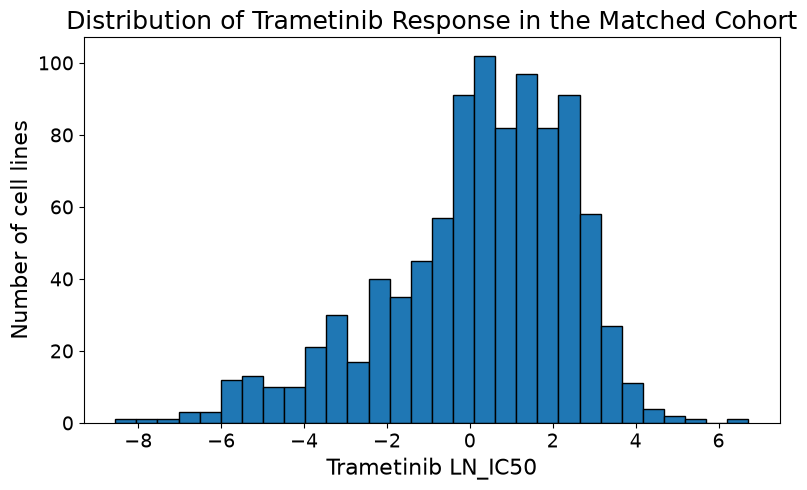

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    trametinib_matched["LN_IC50"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Trametinib LN_IC50", fontsize=16)
plt.ylabel("Number of cell lines", fontsize=16)
plt.title("Distribution of Trametinib Response in the Matched Cohort", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

Trametinib LN_IC50 values showed substantial variation across the 948 matched cancer cell lines, indicating considerable heterogeneity in drug response. This variability supports the use of LN_IC50 as a continuous outcome variable for subsequent regression modelling. Lower LN_IC50 values indicate greater sensitivity to Trametinib, whereas higher values indicate increased resistance.

## 4.2. Outlier Identification

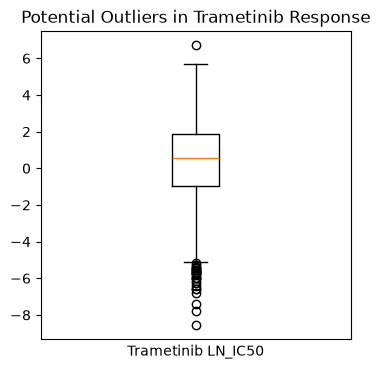

In [27]:
plt.figure(figsize=(4, 4))

plt.boxplot(trametinib["LN_IC50"], orientation="vertical")

plt.xlabel("Trametinib LN_IC50")
plt.xticks([])          # Removes the "1"
plt.title("Potential Outliers in Trametinib Response")

plt.show()

The boxplot identified several observations beyond the conventional interquartile range (IQR) whiskers at both extremes of the LN_IC50 distribution. These observations were retained because they are likely to reflect genuine biological variation in Trametinib sensitivity rather than measurement or data-entry errors. Removing these values could exclude highly sensitive or highly resistant cell lines that are biologically relevant to the research question.

## 4.3. Cancer-Type Composition of the Matched Cohort

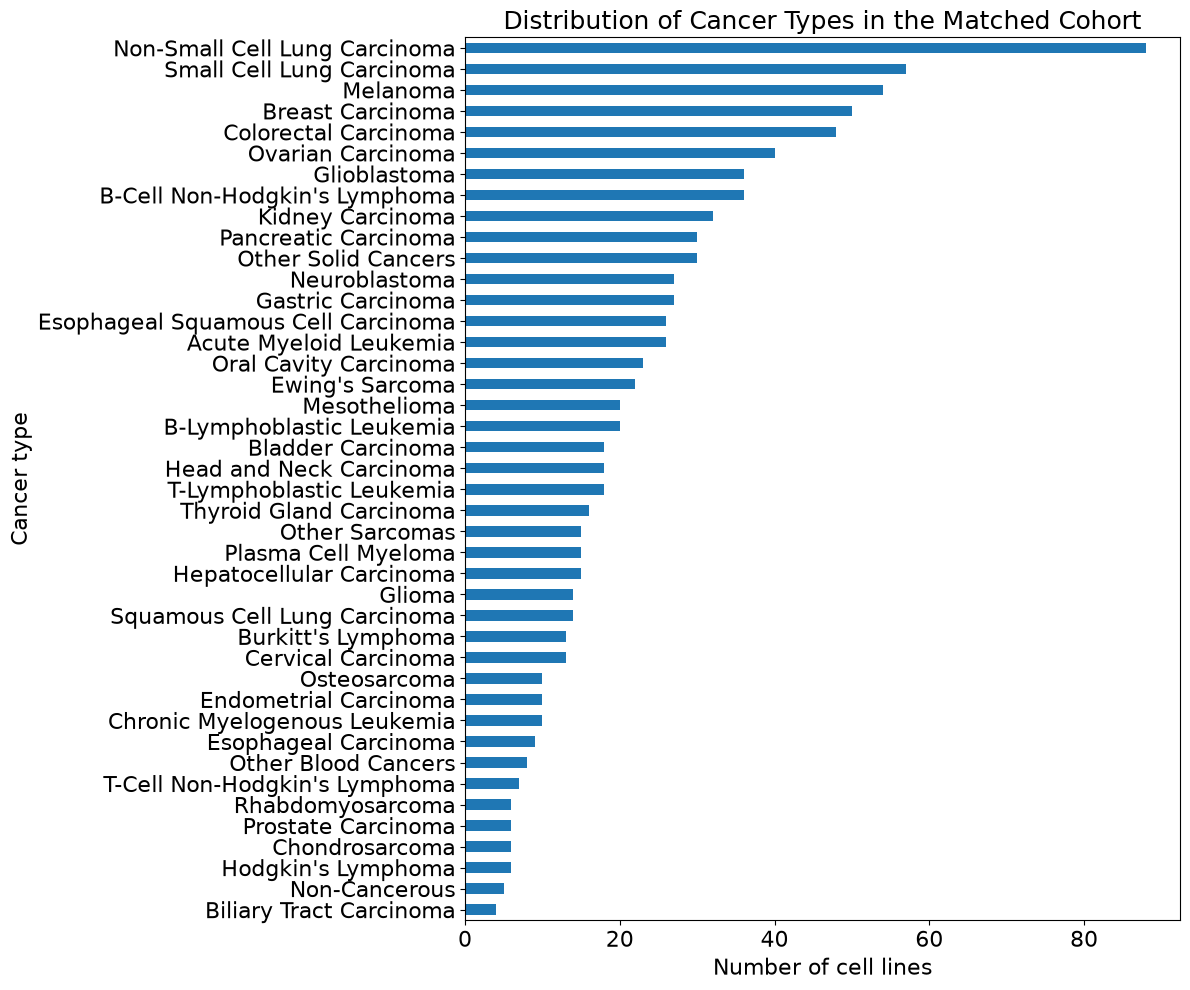

In [28]:
cancer_counts = trametinib_matched["CANCER_TYPE"].value_counts()

plt.figure(figsize=(12, 10))
cancer_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of cell lines", fontsize=16)
plt.ylabel("Cancer type", fontsize=16)
plt.title("Distribution of Cancer Types in the Matched Cohort", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

The matched cohort comprised 948 cancer cell-line models representing 42 tumour types. The cell lines span numerous cancer types, including lung adenocarcinoma, small cell lung cancer, skin cutaneous melanoma, breast cancer and colorectal adenocarcinoma. This diversity provides a broad biological context for investigating genomic predictors of Trametinib response. Cancer type may later be considered as a categorical predictor or potential confounder.

## 4.4 Overall Driver Mutation Burden

The number of unique mutated genes was calculated for each cancer cell line to quantify mutation burden across the matched cohort. This provides an overview of the variability in genomic alterations between cell lines and forms the basis for investigating whether overall mutation burden is associated with Trametinib sensitivity.

In [29]:
# Calculate mutation burden by counting the number of unique mutated genes present in each cancer cell line.

gene_counts_per_cell_line = (
    merged_gene_level.groupby("SANGER_MODEL_ID")["gene_symbol"]
    .nunique()
    .sort_values(ascending=False)
)

gene_counts_per_cell_line.head()

SANGER_MODEL_ID
SIDM00217    114
SIDM00282    108
SIDM01045     91
SIDM00193     77
SIDM01016     68
Name: gene_symbol, dtype: int64

Mutation burden varied considerably across the matched cancer cell lines. The most highly mutated models contained between 68 and 114 unique mutated genes, demonstrating substantial heterogeneity in the number of genomic alterations present within the cohort.

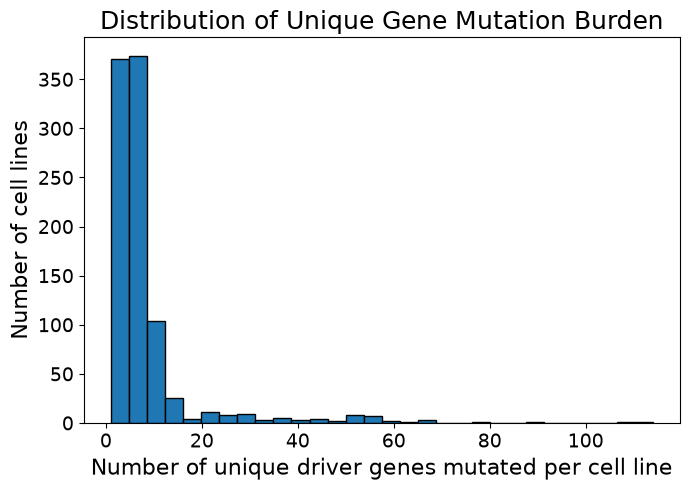

In [30]:
plt.figure(figsize=(7, 5))
plt.hist(
    gene_counts_per_cell_line,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Number of unique driver genes mutated per cell line", fontsize=16)
plt.ylabel("Number of cell lines", fontsize=16)
plt.title("Distribution of Unique Gene Mutation Burden", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
display(gene_counts_per_cell_line.describe())

count    948.000000
mean       8.264768
std       11.337789
min        1.000000
25%        4.000000
50%        5.000000
75%        8.000000
max      114.000000
Name: gene_symbol, dtype: float64


The distribution of unique mutated genes per cell line was strongly right-skewed. Most cancer cell lines harboured relatively few mutated genes (median = 5; IQR = 4–8), whereas a small number exhibited substantially higher mutation burdens, with a maximum of 114 unique mutated genes. The mean mutation burden (8.3 genes per cell line) exceeded the median because of these highly mutated outliers. This variability suggests that mutation burden differs considerably across the matched cohort and may contribute to differences in Trametinib response.

## 4.5. Gene Mutation Prevalence

In [32]:
# Calculate mutation prevalence by counting the number of unique cell lines harbouring a mutation in each gene.
mutation_prevalence = (
    merged_gene_level
    .groupby("gene_symbol")["SANGER_MODEL_ID"]
    .nunique()
    .sort_values(ascending=False)
)

mutation_prevalence.head(20)

gene_symbol
TP53       643
KRAS       125
KMT2C      124
PTEN       106
KMT2D      104
RB1         97
PIK3CA      93
EP300       87
HLA-A       84
ARID1A      84
BRAF        82
SDHA        78
CDKN2A      76
LRP1B       71
POLQ        69
CREBBP      66
HLA-B       64
SMARCA4     63
CBLC        63
FAT3        63
Name: SANGER_MODEL_ID, dtype: int64

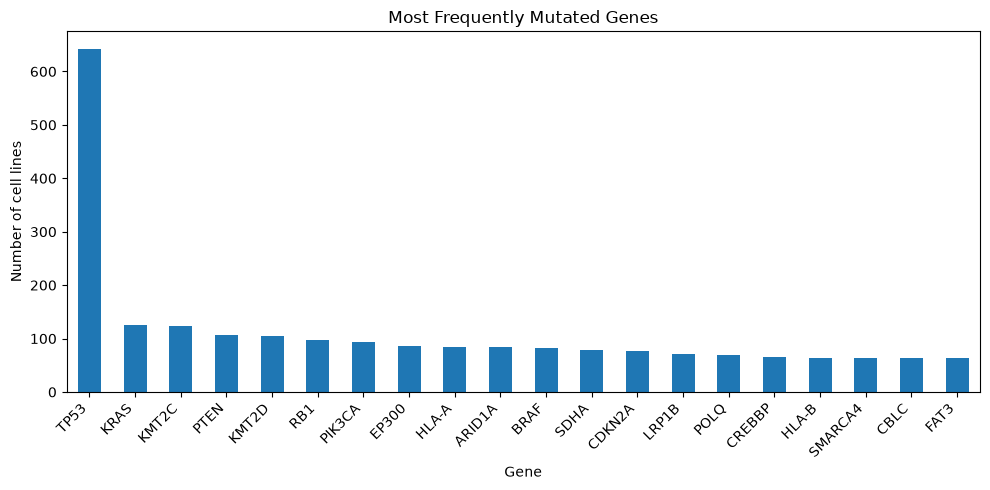

In [33]:
plt.figure(figsize=(10,5))

mutation_prevalence.head(20).plot(kind="bar")

plt.ylabel("Number of cell lines")
plt.xlabel("Gene")
plt.title("Most Frequently Mutated Genes")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

The 948 cancer cell lines with both Trametinib response and mutation data contained 8,522 mutation records spanning 597 unique genes. TP53 was the most frequently mutated gene in the matched cohort, followed by KRAS, KMT2C, PTEN and KMT2D. Several genes involved in the MAPK signalling pathway, including KRAS, BRAF and NRAS, were also recurrently mutated. Given that Trametinib targets the MAPK pathway through MEK1/2 inhibition, the prevalence of these mutations provides a biological rationale for investigating their association with drug sensitivity. Mutation frequency should not be interpreted as predictive importance, as common mutations are not necessarily the strongest predictors of drug response. Data shown for the top 20 most frequently mutated genes.

## 4.6. MAPK Pathway Alterations

Trametinib acts by inhibiting MEK1/2 in the MAPK signalling pathway. Therefore, mutations in MAPK-related genes are of particular interest and were identified using a predefined gene set.

In [34]:
# MAPK-pathway genes used for this analysis were based on a predefined MAPK pathway gene set and used to annotate mutation records for pathway-level analysis

mapk_pathway_gene_set = {
    # RAS family and regulators
    "KRAS", "NRAS", "HRAS",
    "NF1", "RASA1", "RASA2", "RASA3", "RASA4",

    # RAF proteins
    "BRAF", "RAF1", "ARAF",

    # MEK proteins
    "MAP2K1", "MAP2K2",

    # ERK proteins
    "MAPK1", "MAPK3",

    # Receptor tyrosine kinases
    "EGFR", "ERBB2", "ERBB3", "ERBB4",
    "FGFR1", "FGFR2", "FGFR3", "FGFR4",
    "MET", "KIT", "PDGFRA", "PDGFRB",
    "ALK", "RET", "ROS1",

    # Upstream signalling proteins
    "SOS1", "SOS2", "GRB2", "SHC1",

    # MAPK phosphatases and feedback regulators
    "DUSP4", "DUSP5", "DUSP6",
    "SPRY1", "SPRY2", "SPRY4",

    # Other MAPK pathway members
    "MAP3K1", "MAP3K2", "MAP3K3", "MAP3K4",
    "MAP3K5", "MAP3K7", "MAP3K8",
    "MAP2K3", "MAP2K4", "MAP2K5", "MAP2K6", "MAP2K7",
    "MAPK7", "MAPK8", "MAPK9", "MAPK10",
    "MAPK11", "MAPK12", "MAPK13", "MAPK14"
}

print("Number of genes in MAPK gene set:", len(mapk_pathway_gene_set))

Number of genes in MAPK gene set: 60


In [35]:
# Create a simplified analysis table containing only the variables required for pathway-specific analyses, reducing unnecessary complexity.

mapk_data = merged_gene_level[
    ["SANGER_MODEL_ID", "gene_symbol", "LN_IC50"]
].copy()

display(mapk_data.head())
print("Initial shape:", mapk_data.shape)

,SANGER_MODEL_ID,gene_symbol,LN_IC50
0,SIDM01132,TP53,2.272281
1,SIDM01132,GMPS,2.272281
2,SIDM00848,TP53,1.221512
3,SIDM00848,BRAF,1.221512
4,SIDM00263,TP53,2.590889


Initial shape: (7835, 3)


The resulting dataset contains one row per mutated gene within each cancer cell line, together with the corresponding Trametinib LN_IC50 value. This structure enables identification of MAPK pathway mutations and comparison of drug response between cell lines with and without specific pathway alterations.

In [36]:
# Annotate each mutation according to whether the affected gene belongs to the predefined MAPK signalling pathway.

mapk_data["is_MAPK_mutation"] = (
    mapk_data["gene_symbol"].isin(mapk_pathway_gene_set)
)

print(mapk_data["is_MAPK_mutation"].value_counts())

is_MAPK_mutation
False    7285
True      550
Name: count, dtype: int64


Each mutation record was classified according to whether the mutated gene belonged to the predefined MAPK pathway gene set. Of the 7,835 mutation records in the matched dataset, 550 (7.0%) occurred in MAPK pathway genes, while the remaining 7,285 (93.0%) occurred in genes outside the pathway. This annotation was used to identify cancer cell lines harbouring MAPK pathway mutations for subsequent analyses.

The number of unique cancer cell lines harbouring a mutation in each MAPK-related gene was next calculated. Counting unique cell lines prevents the same model from being counted more than once for a given gene and allows the most prevalent MAPK pathway alterations in the matched cohort to be identified.

In [37]:
# Count the number of unique cell lines mutated in each MAPK-related gene

mapk_gene_frequencies = (
    mapk_data.loc[
        mapk_data["is_MAPK_mutation"]
    ]
    .groupby("gene_symbol")["SANGER_MODEL_ID"]
    .nunique()
    .sort_values(ascending=False)
)

display(mapk_gene_frequencies)
print(f"Total MAPK-mutated cell-line/gene combinations: {(mapk_gene_frequencies).sum()}")

gene_symbol
KRAS      125
BRAF       82
NRAS       59
NF1        56
EGFR       21
RASA1      17
ERBB2      16
MAP2K4     15
ERBB4      14
MAP2K1     14
MAP2K7     12
ALK        12
RASA2      12
MET        11
FGFR4      10
ERBB3      10
FGFR2       8
MAP3K1      8
HRAS        8
RET         7
SOS1        7
FGFR3       7
KIT         6
PDGFRA      5
RAF1        4
FGFR1       2
PDGFRB      1
MAP2K2      1
Name: SANGER_MODEL_ID, dtype: int64

Total MAPK-mutated cell-line/gene combinations: 550


MAPK-related mutations were distributed across multiple genes, with some alterations occurring considerably more frequently than others. The summed frequency represents the total number of MAPK-mutated cell line–gene combinations, rather than the number of unique MAPK-mutated cell lines, because a single cell line may contain mutations in more than one MAPK-related gene.

In [38]:
# Define key genes within the MAPK signalling pathway.

key_mapk_driver_genes = [
    "KRAS",
    "BRAF",
    "NRAS",
    "NF1",
    "MAP2K1",
    "HRAS",
    "RAF1",
    "MAP2K2"
]

In [39]:
# Extract the prevalence of key MAPK pathway genes from the overall mutation prevalence table to focus on genes most directly involved in MEK signalling and Trametinib response.

key_mapk_driver_prevalence = (
    mutation_prevalence
    .reindex(key_mapk_driver_genes)
    .fillna(0)
    .astype(int)
    .sort_values(ascending=False)
)

display(key_mapk_driver_prevalence)
print(f"Total key MAPK mutated cell-line/gene combinations: {(key_mapk_driver_prevalence).sum()}")

gene_symbol
KRAS      125
BRAF       82
NRAS       59
NF1        56
MAP2K1     14
HRAS        8
RAF1        4
MAP2K2      1
Name: SANGER_MODEL_ID, dtype: int64

Total key MAPK mutated cell-line/gene combinations: 349


A subset of key MAPK genes was selected because these genes play a central role in the signalling pathway targeted by Trametinib. Mutations in these genes are more likely to influence how cancer cells respond to MEK inhibition than mutations in genes that are only indirectly linked to the pathway. KRAS was most commonly mutated followed by BRAF.

## 4.7. MAPK Mutation Burden and Trametinib Response

To investigate whether alterations across the MAPK signalling pathway were associated with Trametinib response, the number of mutated MAPK pathway genes was counted for each cell line. This generated a single feature, termed the MAPK mutation count, representing the number of MAPK pathway genes carrying driver mutations in each cell line.

In [40]:
# The number of MAPK pathway mutations was calculated for each cancer cell line for use in downstream analyses.

mapk_mutation_counts = (
    mapk_data
    .groupby("SANGER_MODEL_ID")["is_MAPK_mutation"]
    .sum()
    .rename("MAPK_mutation_count")
)

display(mapk_mutation_counts.head())

SANGER_MODEL_ID
SIDM00003    2
SIDM00023    0
SIDM00040    0
SIDM00042    1
SIDM00043    0
Name: MAPK_mutation_count, dtype: int64

In [41]:
# The corresponding Trametinib LN_IC50 value was extracted for each cancer cell line.

cell_line_ic50 = (
    mapk_data.groupby("SANGER_MODEL_ID")["LN_IC50"]
    .first()
    .rename("LN_IC50")
)

display(cell_line_ic50.head())

SANGER_MODEL_ID
SIDM00003   -6.416117
SIDM00023    0.550402
SIDM00040   -0.228455
SIDM00042   -1.140312
SIDM00043   -0.671703
Name: LN_IC50, dtype: float64

In [42]:
# The MAPK mutation burden and corresponding Trametinib LN_IC50 values were combined to create a single cell line-level dataset for downstream analyses.

cell_line_mapk = pd.concat(
    [mapk_mutation_counts, cell_line_ic50],
    axis=1
).reset_index()

display(cell_line_mapk.head())


,SANGER_MODEL_ID,MAPK_mutation_count,LN_IC50
0,SIDM00003,2,-6.416117
1,SIDM00023,0,0.550402
2,SIDM00040,0,-0.228455
3,SIDM00042,1,-1.140312
4,SIDM00043,0,-0.671703


In [43]:
print(
    "Duplicate cell-line IDs:",
    cell_line_mapk["SANGER_MODEL_ID"].duplicated().sum()
)

print("\nMissing values:")
print(cell_line_mapk.isna().sum())

print("\nMAPK mutation count summary:")
display(cell_line_mapk["MAPK_mutation_count"].describe())

Duplicate cell-line IDs: 0

Missing values:
SANGER_MODEL_ID        0
MAPK_mutation_count    0
LN_IC50                0
dtype: int64

MAPK mutation count summary:


count    948.000000
mean       0.580169
std        0.803180
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        6.000000
Name: MAPK_mutation_count, dtype: float64

The final cell line-level dataset contained no duplicate identifiers or missing values. Most cancer cell lines had no MAPK pathway mutations (median = 0; IQR = 0–1), although a small number harboured multiple mutations, with a maximum of six. This indicates that MAPK pathway mutations were relatively uncommon but showed sufficient variability for downstream statistical analyses.

In [44]:
# Calculate both Pearson and Spearman correlations because mutation counts are discrete and the relationship with LN_IC50 may not be strictly linear.

pearson_r, pearson_p = pearsonr(
    cell_line_mapk["MAPK_mutation_count"],
    cell_line_mapk["LN_IC50"]
)

spearman_r, spearman_p = spearmanr(
    cell_line_mapk["MAPK_mutation_count"],
    cell_line_mapk["LN_IC50"]
)


print("Pearson correlation")
print(f"r = {pearson_r:.3f}")
print(f"p = {pearson_p:.4g}")

print("\nSpearman correlation")
print(f"rho = {spearman_r:.3f}")
print(f"p = {spearman_p:.4g}")

Pearson correlation
r = -0.306
p = 5.332e-22

Spearman correlation
rho = -0.375
p = 5.461e-33


Both Pearson (r = −0.306, p < 0.001) and Spearman (ρ = −0.375, p < 0.001) correlation analyses identified a statistically significant negative association between MAPK mutation burden and Trametinib LN_IC50. Cancer cell lines with a greater number of MAPK pathway mutations tended to have lower LN_IC50 values, indicating increased sensitivity to Trametinib. The stronger Spearman correlation suggests the association may not be fully linear and that rank-based relationships better capture the trend.

In [45]:
# Number of cell lines in each MAPK mutation-count group

mapk_count_distribution = (
    cell_line_mapk["MAPK_mutation_count"]
    .value_counts()
    .sort_index()
)

print(mapk_count_distribution)

MAPK_mutation_count
0    527
1    330
2     69
3     12
4      5
5      4
6      1
Name: count, dtype: int64


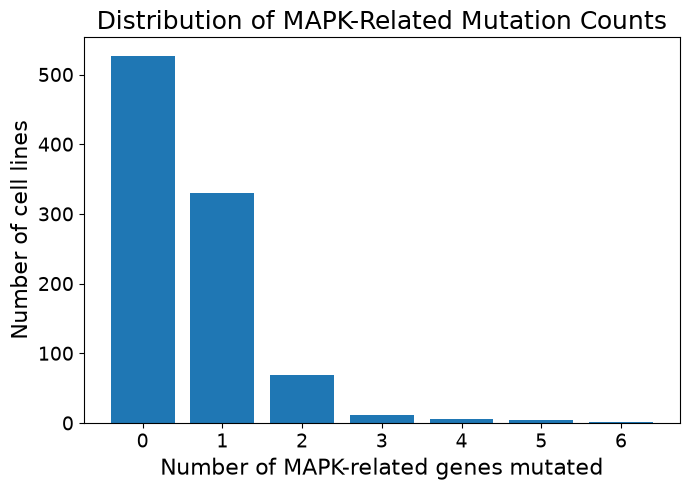

In [46]:
plt.figure(figsize=(7, 5))

plt.bar(
    mapk_count_distribution.index.astype(str),
    mapk_count_distribution.values
)
plt.title("Distribution of MAPK-Related Mutation Counts", fontsize=18)
plt.xlabel("Number of MAPK-related genes mutated", fontsize=16)
plt.ylabel("Number of cell lines", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

MAPK mutation burden was generally low across the cohort which may limit statistical power for groups with higher mutation counts. Most cancer cell lines had zero or one MAPK pathway mutation, whereas only a small proportion harboured multiple MAPK mutations (maximum = 6).

A boxplot was generated to compare Trametinib LN_IC50 across increasing levels of MAPK mutation burden. Sample sizes for each mutation burden group are shown on the x-axis.

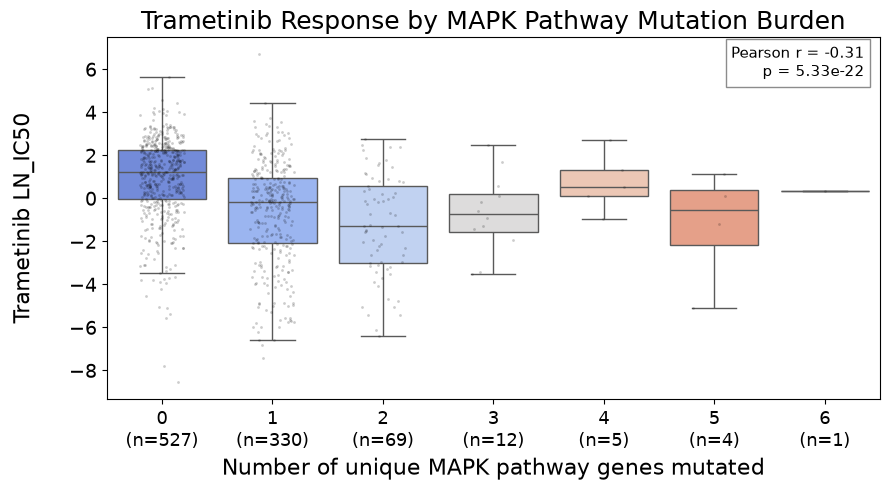

In [47]:
# Order the MAPK mutation burden groups and calculate sample sizes
mapk_group_sizes = (
    cell_line_mapk["MAPK_mutation_count"]
    .value_counts()
    .sort_index()
)

mapk_order = mapk_group_sizes.index.tolist()

# Create x-axis labels including sample sizes
mapk_tick_labels = [
    f"{count}\n(n={mapk_group_sizes.loc[count]})"
    for count in mapk_order
]

# Create a blue-to-red colour palette
palette = sns.color_palette("coolwarm", n_colors=len(mapk_order))

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=cell_line_mapk,
    x="MAPK_mutation_count",
    y="LN_IC50",
    order=mapk_order,
    hue="MAPK_mutation_count",
    palette=palette,
    showfliers=False,
    legend=False
)

sns.stripplot(
    data=cell_line_mapk,
    x="MAPK_mutation_count",
    y="LN_IC50",
    order=mapk_order,
    color="black",
    alpha=0.20,
    size=2,
    jitter=0.20
)

# Add Pearson correlation statistics
plt.text(
    0.98,
    0.98,
    f"Pearson r = {pearson_r:.2f}\np = {pearson_p:.2e}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="grey", alpha=0.9)
)

plt.title(
    "Trametinib Response by MAPK Pathway Mutation Burden",
    fontsize=18
)

plt.xlabel(
    "Number of unique MAPK pathway genes mutated",
    fontsize=16
)

plt.ylabel(
    "Trametinib LN_IC50\n",
    fontsize=16
)

plt.xticks(
    ticks=range(len(mapk_order)),
    labels=mapk_tick_labels,
    fontsize=13
)

plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

Trametinib LN_IC50 generally decreased as MAPK mutation burden increased, indicating greater sensitivity in cell lines harbouring more MAPK pathway mutations. However, the groups with higher mutation burdens contained relatively few cell lines, so these findings should be interpreted with caution.

## 4.8. KRAS Mutation Status and Trametinib Response

Following the pathway-level analysis, KRAS was selected for further investigation because it was the most frequently mutated MAPK-related gene in the matched cohort. This enabled the association between KRAS mutation status and Trametinib sensitivity to be examined at the individual gene level.

In [48]:
# Identify all cell lines carrying a KRAS mutation so that drug response can be compared between mutant and wild-type groups.

kras_models = set(
    trametinib_mutations.loc[
        trametinib_mutations["gene_symbol"] == "KRAS",
        "model_id"
    ]
)

In [49]:
# Each matched cancer cell line was classified as either KRAS-mutant or KRAS wild type based on the presence of a KRAS mutation.

trametinib_matched["KRAS_status"] = np.where(
    trametinib_matched["SANGER_MODEL_ID"].isin(kras_models),
    "Mutant",
    "Wild type"
)

In [50]:
# Descriptive statistics for Trametinib LN_IC50 were calculated for the KRAS-mutant and KRAS wild-type groups.

kras_summary = (
    trametinib_matched
    .groupby("KRAS_status")["LN_IC50"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        standard_deviation="std"
    )
)

display(kras_summary)

,n,median,mean,standard_deviation
KRAS_status,,,,
Mutant,125,-0.763416,-0.924487,2.130917
Wild type,823,0.699956,0.370197,2.241659


KRAS-mutant cell lines (n = 125) showed lower median LN_IC50 values than KRAS wild-type cell lines (−0.76 vs 0.70), indicating greater sensitivity to Trametinib. Statistical testing was subsequently performed to assess whether this difference was significant.

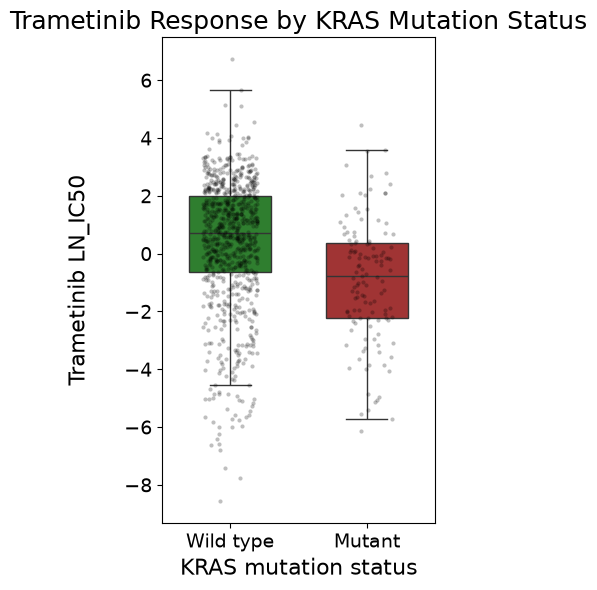

In [51]:
plt.figure(figsize=(4, 6))

sns.boxplot(
    data=trametinib_matched,
    x="KRAS_status",
    y="LN_IC50",
    hue="KRAS_status",
    order=["Wild type", "Mutant"],
    palette={
        "Wild type": "forestgreen",
        "Mutant": "firebrick"
    },
    legend=False,
    width=0.6, 
    showfliers=False
)

sns.stripplot(
    data=trametinib_matched,
    x="KRAS_status",
    y="LN_IC50",
    order=["Wild type", "Mutant"],
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.2
)
plt.title("Trametinib Response by KRAS Mutation Status", fontsize=18)
plt.xlabel("KRAS mutation status", fontsize=16)
plt.ylabel(
    "Trametinib LN_IC50\n", fontsize=16
)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()


In [52]:
# Extract Trametinib LN_IC50 values for KRAS-mutant cell lines.

kras_mutant_ln_ic50 = trametinib_matched.loc[
    trametinib_matched["KRAS_status"] == "Mutant",
    "LN_IC50"
]

# Extract Trametinib LN_IC50 values for KRAS-mutant cell lines.

kras_wildtype_ln_ic50 = trametinib_matched.loc[
    trametinib_matched["KRAS_status"] == "Wild type",
    "LN_IC50"
]

# Compare the distributions of Trametinib response between the two groups using a non-parametric Mann–Whitney U test, which does not assume normally distributed LN_IC50 values.

kras_u_statistic, kras_p_value = mannwhitneyu(
    kras_mutant_ln_ic50,
    kras_wildtype_ln_ic50,
    alternative="two-sided"
)

print(
    f"KRAS Mann–Whitney U statistic: "
    f"{kras_u_statistic:.0f}"
)

print(f"KRAS p-value: {kras_p_value:.3e}")

KRAS Mann–Whitney U statistic: 32197
KRAS p-value: 1.526e-11


The boxplot indicates that KRAS-mutant cell lines tended to have lower LN_IC50 values than KRAS wild-type cell lines, consistent with increased sensitivity to Trametinib. The Mann–Whitney U test confirmed that this difference was statistically significant (U = 32,197, p < 0.001). These findings suggest that KRAS mutation status is associated with increased sensitivity to Trametinib in this cohort of cancer cell lines,  although considerable overlap between the two distributions suggests that KRAS mutation status alone is unlikely to fully explain drug response.

## 4.9. BRAF Mutation Status and Trametinib Response

BRAF was also examined because it was one of the most frequently mutated MAPK pathway genes and functions directly upstream of MEK1/2, the molecular targets of Trametinib.

In [53]:
# Identify all cell lines carrying a BRAF mutation so that drug response can be compared between mutant and wild-type groups.

braf_models = set(
    trametinib_mutations.loc[
        trametinib_mutations["gene_symbol"] == "BRAF",
        "model_id"
    ]
)

In [54]:
# Each matched cancer cell line was classified as either BRAF-mutant or BRAF wild type based on the presence of a BRAF mutation.

trametinib_matched["BRAF_status"] = np.where(
    trametinib_matched["SANGER_MODEL_ID"].isin(braf_models),
    "Mutant",
    "Wild type"
)

In [55]:
# Calculate descriptive statistics for Trametinib LN_IC50 in the BRAF-mutant and BRAF wild-type groups to summarise differences in drug response before formal statistical testing.

braf_summary = (
    trametinib_matched
    .groupby("BRAF_status")["LN_IC50"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        standard_deviation="std"
    )
)

display(braf_summary)

,n,median,mean,standard_deviation
BRAF_status,,,,
Mutant,82,-2.398931,-2.510984,2.370481
Wild type,866,0.675580,0.456134,2.085157


BRAF-mutant cell lines (n = 82) had markedly lower median LN_IC50 values than BRAF wild-type cell lines (−2.40 vs 0.68), indicating substantially greater sensitivity to Trametinib. Statistical testing was subsequently performed to assess whether this difference was significant

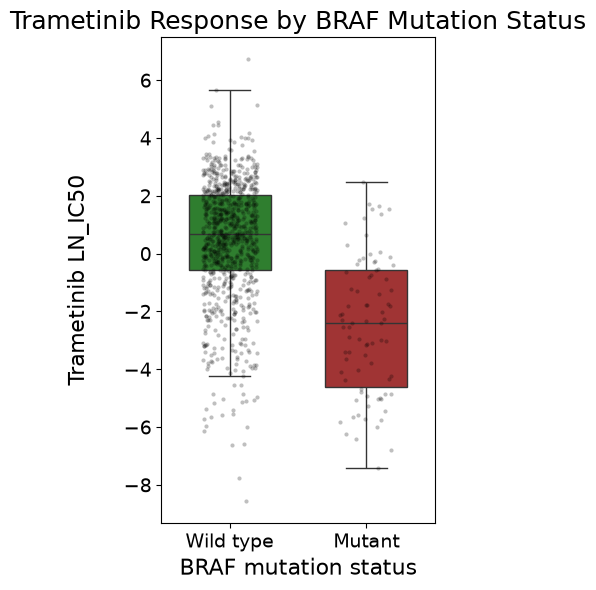

In [56]:
plt.figure(figsize=(4, 6))

sns.boxplot(
    data=trametinib_matched,
    x="BRAF_status",
    y="LN_IC50",
    order=["Wild type", "Mutant"],
    hue="BRAF_status",
    palette={
        "Wild type": "forestgreen",
        "Mutant": "firebrick"
    },
    legend=False,
    width=0.6, 
    showfliers=False
)

sns.stripplot(
    data=trametinib_matched,
    x="BRAF_status",
    y="LN_IC50",
    order=["Wild type", "Mutant"],
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.2
)
plt.title("Trametinib Response by BRAF Mutation Status", fontsize=18)
plt.xlabel("BRAF mutation status", fontsize=16)
plt.ylabel(
    "Trametinib LN_IC50\n", fontsize=16
)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()


In [57]:
# Extract Trametinib LN_IC50 values for BRAF-mutant cell lines.

braf_mutant_ln_ic50 = trametinib_matched.loc[
    trametinib_matched["BRAF_status"] == "Mutant",
    "LN_IC50"
]

# Extract Trametinib LN_IC50 values for BRAF wild-type cell lines.
braf_wildtype_ln_ic50 = trametinib_matched.loc[
    trametinib_matched["BRAF_status"] == "Wild type",
    "LN_IC50"
]

# Compare the distributions of Trametinib response between the two groups using a non-parametric Mann–Whitney U test, which does not assume normally distributed LN_IC50 values.

braf_u_statistic, braf_p_value = mannwhitneyu(
    braf_mutant_ln_ic50,
    braf_wildtype_ln_ic50,
    alternative="two-sided"
)

print(
    f"BRAF Mann–Whitney U statistic: "
    f"{braf_u_statistic:.0f}"
)

print(f"BRAF p-value: {braf_p_value:.3e}")

BRAF Mann–Whitney U statistic: 12267
BRAF p-value: 1.059e-22


The boxplot demonstrated that BRAF-mutant cell lines tended to have substantially lower LN_IC50 values than BRAF wild-type cell lines, indicating greater sensitivity to Trametinib. The Mann–Whitney U test confirmed that this difference was highly statistically significant (U = 12,267, p < 0.001). These findings suggest that BRAF mutation status is strongly associated with increased sensitivity to Trametinib in this cohort of cancer cell lines.

## 4.10 Exploratory Analysis Summary

Exploratory analyses demonstrated substantial variation in Trametinib response across the 948 matched cancer cell lines, supporting the use of LN_IC50 as the continuous response variable for downstream machine learning models. The matched cohort contained recurrent mutations in several established cancer driver genes, including TP53, KRAS, BRAF, PTEN and PIK3CA.

As Trametinib targets the MAPK signalling pathway, particular attention was given to mutations within this pathway. MAPK mutation burden showed a statistically significant negative association with Trametinib LN_IC50, indicating that cell lines with a greater number of MAPK pathway mutations tended to exhibit increased drug sensitivity. Similarly, both KRAS-mutant and BRAF-mutant cell lines exhibited significantly lower LN_IC50 values than their respective wild-type groups, although considerable variability remained within each group.

These findings suggest that while MAPK pathway alterations are associated with Trametinib sensitivity, they do not fully explain the observed variation in drug response. Consequently, the next stage of the analysis investigates whether multivariable machine learning models incorporating the broader mutation profile can more accurately predict Trametinib sensitivity. 

Collectively these findings justify progressing to multivariable machine learning models capable of capturing interactions between multiple genomic features.

# 5. Next Steps

The exploratory analyses presented in this notebook established a validated and biologically relevant dataset linking cancer driver mutations with experimentally measured Trametinib response. The analyses identified significant associations between MAPK pathway alterations and drug sensitivity, while also demonstrating that substantial variability in response remains unexplained by individual genes or pathway-level summaries alone.

The next stage of the project will transform the long-format mutation dataset into a machine-learning-ready feature matrix, where each cancer cell line is represented by its genomic mutation profile. Supervised machine learning models will then be developed to predict Trametinib sensitivity using these genomic features. Model performance will be evaluated using standard regression metrics, and feature importance analyses will be used to identify the mutations that contribute most strongly to predictive performance.